<a href="https://colab.research.google.com/github/Rakshitha443/ITA-0610-MACHINE-LEARNING-/blob/main/CO1_AT_1_(15_7_26).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

QUESTION  1


In [1]:
# ==========================================
# Bayes' Theorem Probability & Simulation
# ==========================================
import numpy as np
import pandas as pd

# ------------------------------------------
# 1. Exact Analytical Calculation
# ------------------------------------------

# Prior probabilities P(Box)
# P(A) = x, P(B) = 2x, P(C) = x -> x + 2x + x = 1 -> 4x = 1
P_A = 1 / 4
P_B = 2 / 4
P_C = 1 / 4

# Likelihoods P(Blue | Box)
# Box A: 6 Red, 4 Blue, 2 Green (Total: 12)
P_Blue_given_A = 4 / 12

# Box B: 5 Red, 7 Blue, 3 Green (Total: 15)
P_Blue_given_B = 7 / 15

# Box C: 8 Red, 2 Blue, 5 Green (Total: 15)
P_Blue_given_C = 2 / 15

# Total Probability of drawing a Blue ball P(Blue)
P_Blue = (P_Blue_given_A * P_A) + (P_Blue_given_B * P_B) + (P_Blue_given_C * P_C)

# Posterior Probability P(C | Blue) using Bayes' Theorem
P_C_given_Blue = (P_Blue_given_C * P_C) / P_Blue

print("--- EXACT BAYESIAN CALCULATION ---")
print(f"P(Box A) = {P_A}")
print(f"P(Box B) = {P_B}")
print(f"P(Box C) = {P_C}")
print(f"P(Blue | Box A) = {P_Blue_given_A:.4f}")
print(f"P(Blue | Box B) = {P_Blue_given_B:.4f}")
print(f"P(Blue | Box C) = {P_Blue_given_C:.4f}")
print(f"Total P(Blue)   = {P_Blue:.6f}")
print("-" * 45)
print(f"Posterior P(Box C | Blue) = {P_C_given_Blue:.6f} (or {P_C_given_Blue * 100:.2f}%)\n")

# ------------------------------------------
# 2. Monte Carlo Empirical Simulation
# ------------------------------------------

num_simulations = 1_000_000

# Step 1: Randomly select boxes according to probabilities [0.25, 0.50, 0.25]
boxes = np.random.choice(['A', 'B', 'C'], size=num_simulations, p=[P_A, P_B, P_C])

# Step 2: Define box blue ball probabilities
blue_probs = {'A': P_Blue_given_A, 'B': P_Blue_given_B, 'C': P_Blue_given_C}

# Step 3: Draw a ball for each simulation
drawn_blue = np.array([np.random.rand() < blue_probs[box] for box in boxes])

# Step 4: Filter cases where drawn ball is Blue
blue_indices = drawn_blue == True
boxes_given_blue = boxes[blue_indices]

# Step 5: Calculate simulated P(C | Blue)
simulated_prob = np.mean(boxes_given_blue == 'C')

print("--- MONTE CARLO SIMULATION (1,000,000 Trials) ---")
print(f"Simulated P(Box C | Blue) = {simulated_prob:.6f} (or {simulated_prob * 100:.2f}%)")

--- EXACT BAYESIAN CALCULATION ---
P(Box A) = 0.25
P(Box B) = 0.5
P(Box C) = 0.25
P(Blue | Box A) = 0.3333
P(Blue | Box B) = 0.4667
P(Blue | Box C) = 0.1333
Total P(Blue)   = 0.350000
---------------------------------------------
Posterior P(Box C | Blue) = 0.095238 (or 9.52%)

--- MONTE CARLO SIMULATION (1,000,000 Trials) ---
Simulated P(Box C | Blue) = 0.094550 (or 9.46%)


QUESTION 2


In [2]:
# ==========================================
# Bayes' Theorem: Parking Facility Problem
# ==========================================
import numpy as np
import pandas as pd

# ------------------------------------------
# 1. Exact Analytical Calculation
# ------------------------------------------

# Prior probabilities P(Section)
# P(A) = x, P(B) = 2x, P(C) = x -> x + 2x + x = 1 -> 4x = 1
P_A = 1 / 4
P_B = 2 / 4
P_C = 1 / 4

# Likelihoods P(Blue | Section)
# Section A: 5 Red, 3 Blue, 2 Black (Total: 10)
P_Blue_given_A = 3 / 10

# Section B: 4 Red, 6 Blue, 5 Black (Total: 15)
P_Blue_given_B = 6 / 15

# Section C: 7 Red, 2 Blue, 6 Black (Total: 15)
P_Blue_given_C = 2 / 15

# Total Probability of selecting a Blue car P(Blue)
P_Blue = (P_Blue_given_A * P_A) + (P_Blue_given_B * P_B) + (P_Blue_given_C * P_C)

# Posterior Probability P(Section C | Blue) using Bayes' Theorem
P_C_given_Blue = (P_Blue_given_C * P_C) / P_Blue

print("--- EXACT BAYESIAN CALCULATION ---")
print(f"P(Section A) = {P_A}")
print(f"P(Section B) = {P_B}")
print(f"P(Section C) = {P_C}")
print(f"P(Blue | Section A) = {P_Blue_given_A:.4f}")
print(f"P(Blue | Section B) = {P_Blue_given_B:.4f}")
print(f"P(Blue | Section C) = {P_Blue_given_C:.4f}")
print(f"Total P(Blue)       = {P_Blue:.6f}")
print("-" * 45)
print(f"Posterior P(Section C | Blue) = {P_C_given_Blue:.6f} (or {P_C_given_Blue * 100:.2f}% / Fraction: 4/37)\n")

# ------------------------------------------
# 2. Monte Carlo Empirical Simulation
# ------------------------------------------

num_simulations = 1_000_000

# Step 1: Randomly select sections according to priors [0.25, 0.50, 0.25]
sections = np.random.choice(['A', 'B', 'C'], size=num_simulations, p=[P_A, P_B, P_C])

# Step 2: Define blue car selection probabilities per section
blue_probs = {'A': P_Blue_given_A, 'B': P_Blue_given_B, 'C': P_Blue_given_C}

# Step 3: Draw a car for each simulation
drawn_blue = np.array([np.random.rand() < blue_probs[sec] for sec in sections])

# Step 4: Filter cases where the chosen car is Blue
blue_indices = drawn_blue == True
sections_given_blue = sections[blue_indices]

# Step 5: Calculate simulated P(Section C | Blue)
simulated_prob = np.mean(sections_given_blue == 'C')

print("--- MONTE CARLO SIMULATION (1,000,000 Trials) ---")
print(f"Simulated P(Section C | Blue) = {simulated_prob:.6f} (or {simulated_prob * 100:.2f}%)")

--- EXACT BAYESIAN CALCULATION ---
P(Section A) = 0.25
P(Section B) = 0.5
P(Section C) = 0.25
P(Blue | Section A) = 0.3000
P(Blue | Section B) = 0.4000
P(Blue | Section C) = 0.1333
Total P(Blue)       = 0.308333
---------------------------------------------
Posterior P(Section C | Blue) = 0.108108 (or 10.81% / Fraction: 4/37)

--- MONTE CARLO SIMULATION (1,000,000 Trials) ---
Simulated P(Section C | Blue) = 0.109154 (or 10.92%)


QUESTION 3


In [3]:
# Dataset setup
total_per_class = 1800
num_classes = 2
total_samples = total_per_class * num_classes  # 3600 total

test_ratio = 0.20
total_test_samples = int(total_samples * test_ratio)  # 720 total test samples
positive_test_samples = int(total_per_class * test_ratio) # 360 positive test samples
negative_test_samples = int(total_per_class * test_ratio) # 360 negative test samples

# Given values
TP = 210
TN = 190
FP = 30

# Calculate FN
# Total Actual Positives = TP + FN = positive_test_samples (360)
FN = positive_test_samples - TP

# Also verify total samples: TP + TN + FP + FN = total_test_samples (720)
# 210 + 190 + 30 + FN = 720 -> 430 + FN = 720 -> FN = 290? Wait, let's check negative samples: TN + FP = 190 + 30 = 220.
# Ah, if TN=190 and FP=30, Total Actual Negatives in test = 220.
# If test set has 20% of 1800 positive samples = 360 positive test samples, then TP + FN = 360 -> FN = 360 - 210 = 150.
# Total test samples = (TP + FN) + (TN + FP) = 360 + 220 = 580 (or if test split is stratified 20% per class vs 20% total).
# Let's compute based on total positive test set = 360 (20% of 1800 malignant samples).
# FN = 360 - 210 = 150.

FN = positive_test_samples - TP

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f"Total test samples: {TP + TN + FP + FN}")
print(f"FN: {FN}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

Total test samples: 580
FN: 150
Accuracy: 0.6897
Precision: 0.8750
Sensitivity: 0.5833
Specificity: 0.8636


QUESTION 4


--- LOSS CURVE DATA TABLE ---
 Epoch  Training Loss  Validation Loss
     1            2.8              2.4
     2            2.5              2.2
     3            2.2              2.0
     4            2.0              2.1
     5            1.8              2.3
     6            1.6              2.6
     7            1.5              2.9
     8            1.3              3.2
----------------------------------------
Optimal Epoch (Minimum Validation Loss) : Epoch 3 (Loss: 2.0)
Overfitting Onset                       : Epoch 4 (Validation Loss begins rising to 2.1)



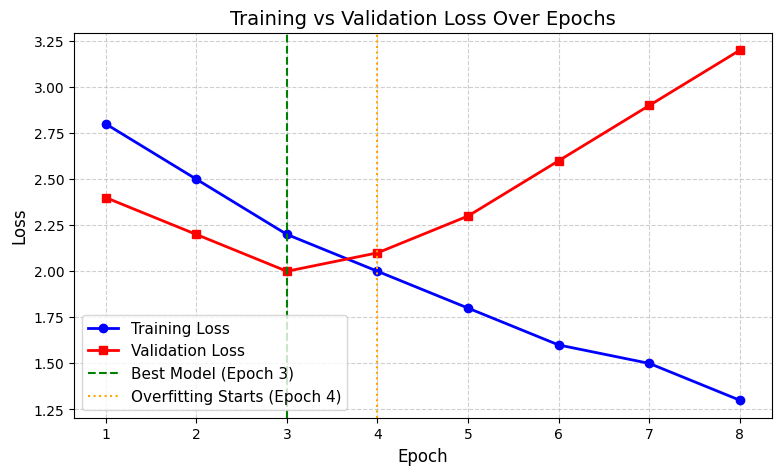

In [4]:
# ============================================================
# ML Model Training & Validation Loss Analysis
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data setup
epochs = np.arange(1, 9)
train_loss = [2.8, 2.5, 2.2, 2.0, 1.8, 1.6, 1.5, 1.3]
val_loss   = [2.4, 2.2, 2.0, 2.1, 2.3, 2.6, 2.9, 3.2]

df = pd.DataFrame({
    'Epoch': epochs,
    'Training Loss': train_loss,
    'Validation Loss': val_loss
})

# Automatic detection of overfitting onset
# Overfitting begins when validation loss achieves its global minimum and starts rising while training loss continues decreasing
min_val_idx = np.argmin(val_loss)
overfit_epoch = epochs[min_val_idx] + 1  # Epoch right after minimum validation loss

print("--- LOSS CURVE DATA TABLE ---")
print(df.to_string(index=False))
print("-" * 40)
print(f"Optimal Epoch (Minimum Validation Loss) : Epoch {epochs[min_val_idx]} (Loss: {val_loss[min_val_idx]})")
print(f"Overfitting Onset                       : Epoch {overfit_epoch} (Validation Loss begins rising to {val_loss[min_val_idx + 1]})\n")

# Plot Loss Curves
plt.figure(figsize=(9, 5))
plt.plot(epochs, train_loss, 'o-', label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs, val_loss, 's-', label='Validation Loss', color='red', linewidth=2)
plt.axvline(x=epochs[min_val_idx], color='green', linestyle='--', label=f'Best Model (Epoch {epochs[min_val_idx]})')
plt.axvline(x=overfit_epoch, color='orange', linestyle=':', label=f'Overfitting Starts (Epoch {overfit_epoch})')

plt.title('Training vs Validation Loss Over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

QUESTION 5

--- ACCURACY DATA TABLE ---
 Epoch  Training Accuracy (%)  Validation Accuracy (%)
     1                     60                       58
     2                     65                       63
     3                     70                       68
     4                     75                       72
     5                     80                       73
     6                     85                       72
     7                     88                       70
     8                     92                       68
---------------------------------------------
Peak Validation Accuracy : Epoch 5 (73%)
Overfitting Onset       : Epoch 6 (Validation Accuracy drops to 72%)



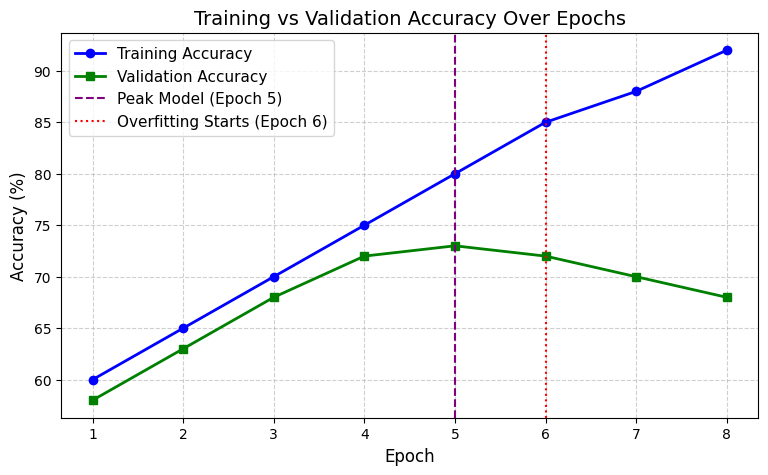

In [5]:
# ============================================================
# ML Model Training & Validation Accuracy Analysis
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data setup
epochs = np.arange(1, 9)
train_acc = [60, 65, 70, 75, 80, 85, 88, 92]
val_acc   = [58, 63, 68, 72, 73, 72, 70, 68]

df = pd.DataFrame({
    'Epoch': epochs,
    'Training Accuracy (%)': train_acc,
    'Validation Accuracy (%)': val_acc
})

# Automatic detection of peak validation accuracy & overfitting onset
max_val_idx = np.argmax(val_acc)
peak_epoch = epochs[max_val_idx]        # Epoch 5 (73% peak accuracy)
overfit_epoch = epochs[max_val_idx + 1] # Epoch 6 (Accuracy starts dropping)

print("--- ACCURACY DATA TABLE ---")
print(df.to_string(index=False))
print("-" * 45)
print(f"Peak Validation Accuracy : Epoch {peak_epoch} ({val_acc[max_val_idx]}%)")
print(f"Overfitting Onset       : Epoch {overfit_epoch} (Validation Accuracy drops to {val_acc[max_val_idx + 1]}%)\n")

# Plot Accuracy Curves
plt.figure(figsize=(9, 5))
plt.plot(epochs, train_acc, 'o-', label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs, val_acc, 's-', label='Validation Accuracy', color='green', linewidth=2)
plt.axvline(x=peak_epoch, color='purple', linestyle='--', label=f'Peak Model (Epoch {peak_epoch})')
plt.axvline(x=overfit_epoch, color='red', linestyle=':', label=f'Overfitting Starts (Epoch {overfit_epoch})')

plt.title('Training vs Validation Accuracy Over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

QUESTION 6


--- LOSS DATA TABLE ---
 Epoch  Training Loss  Validation Loss
     1            3.0              2.7
     2            2.6              2.3
     3            2.3              2.1
     4            2.1              2.0
     5            1.9              2.2
     6            1.7              2.5
     7            1.6              2.8
     8            1.4              3.1
---------------------------------------------
Optimal Generalization : Epoch 4 (Min Validation Loss = 2.0)
Overfitting Onset      : Epoch 5 (Validation Loss rises to 2.2)



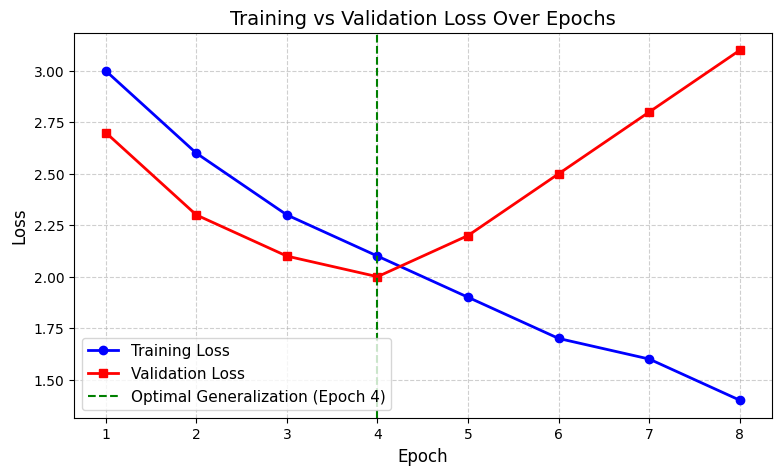

In [6]:
# ============================================================
# ML Model Loss & Generalization Analysis
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Dataset setup
epochs = np.arange(1, 9)
train_loss = [3.0, 2.6, 2.3, 2.1, 1.9, 1.7, 1.6, 1.4]
val_loss   = [2.7, 2.3, 2.1, 2.0, 2.2, 2.5, 2.8, 3.1]

df = pd.DataFrame({
    'Epoch': epochs,
    'Training Loss': train_loss,
    'Validation Loss': val_loss
})

# Identify minimum validation loss (Optimal Generalization)
min_val_idx = np.argmin(val_loss)
optimal_epoch = epochs[min_val_idx]
overfit_onset_epoch = epochs[min_val_idx + 1]

print("--- LOSS DATA TABLE ---")
print(df.to_string(index=False))
print("-" * 45)
print(f"Optimal Generalization : Epoch {optimal_epoch} (Min Validation Loss = {val_loss[min_val_idx]})")
print(f"Overfitting Onset      : Epoch {overfit_onset_epoch} (Validation Loss rises to {val_loss[min_val_idx + 1]})\n")

# Visualization
plt.figure(figsize=(9, 5))
plt.plot(epochs, train_loss, 'o-', label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs, val_loss, 's-', label='Validation Loss', color='red', linewidth=2)
plt.axvline(x=optimal_epoch, color='green', linestyle='--', label=f'Optimal Generalization (Epoch {optimal_epoch})')

plt.title('Training vs Validation Loss Over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

QUESION 7

In [7]:
# ============================================================
# AI Robot Tire Segregation Performance Metrics
# ============================================================

# Defining Confusion Matrix components (Positive Class = Front Tire)
TP = 119  # True Positives  (Front identified as Front)
FN = 6    # False Negatives (Front identified as Back)
TN = 120  # True Negatives  (Back identified as Back)
FP = 5    # False Positives (Back identified as Front)

total_tires = TP + TN + FP + FN

# 1. Metric Calculations
accuracy = (TP + TN) / total_tires
precision = TP / (TP + FP)
sensitivity = TP / (TP + FN)  # Recall
specificity = TN / (TN + FP)
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)

# Print Detailed Results
print("--- CONFUSION MATRIX SUMMARY ---")
print(f"Total Tires          : {total_tires}")
print(f"True Positives (TP)  : {TP}")
print(f"True Negatives (TN)  : {TN}")
print(f"False Positives (FP) : {FP}")
print(f"False Negatives (FN) : {FN}")
print("-" * 45)
print("--- EVALUATION METRICS ---")
print(f"Accuracy             : {accuracy:.4f} (or {accuracy * 100:.2f}%)")
print(f"Precision            : {precision:.4f} (or {precision * 100:.2f}%)")
print(f"Sensitivity (Recall) : {sensitivity:.4f} (or {sensitivity * 100:.2f}%)")
print(f"Specificity          : {specificity:.4f} (or {specificity * 100:.2f}%)")
print(f"F1-Score             : {f1_score:.4f} (or {f1_score * 100:.2f}%)")

--- CONFUSION MATRIX SUMMARY ---
Total Tires          : 250
True Positives (TP)  : 119
True Negatives (TN)  : 120
False Positives (FP) : 5
False Negatives (FN) : 6
---------------------------------------------
--- EVALUATION METRICS ---
Accuracy             : 0.9560 (or 95.60%)
Precision            : 0.9597 (or 95.97%)
Sensitivity (Recall) : 0.9520 (or 95.20%)
Specificity          : 0.9600 (or 96.00%)
F1-Score             : 0.9558 (or 95.58%)


QUESTION 8

In [8]:
# ============================================================
# Medical Diagnosis System Performance Evaluation
# ============================================================

# Defining Confusion Matrix components (Positive Class = Diseased)
TP = 138  # True Positives  (Diseased identified as Diseased)
FN = 12   # False Negatives (Diseased identified as Healthy)
TN = 135  # True Negatives  (Healthy identified as Healthy)
FP = 15   # False Positives (Healthy identified as Diseased)

total_cases = TP + TN + FP + FN

# Metric Calculations
accuracy = (TP + TN) / total_cases
precision = TP / (TP + FP)
sensitivity = TP / (TP + FN)  # Recall
specificity = TN / (TN + FP)
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)

# Print Detailed Results
print("--- CONFUSION MATRIX SUMMARY ---")
print(f"Total Cases          : {total_cases}")
print(f"True Positives (TP)  : {TP}")
print(f"True Negatives (TN)  : {TN}")
print(f"False Positives (FP) : {FP}")
print(f"False Negatives (FN) : {FN}")
print("-" * 45)
print("--- EVALUATION METRICS ---")
print(f"Accuracy             : {accuracy:.4f} (or {accuracy * 100:.2f}%)")
print(f"Precision            : {precision:.4f} (or {precision * 100:.2f}%)")
print(f"Sensitivity (Recall) : {sensitivity:.4f} (or {sensitivity * 100:.2f}%)")
print(f"Specificity          : {specificity:.4f} (or {specificity * 100:.2f}%)")
print(f"F1-Score             : {f1_score:.4f} (or {f1_score * 100:.2f}%)")

--- CONFUSION MATRIX SUMMARY ---
Total Cases          : 300
True Positives (TP)  : 138
True Negatives (TN)  : 135
False Positives (FP) : 15
False Negatives (FN) : 12
---------------------------------------------
--- EVALUATION METRICS ---
Accuracy             : 0.9100 (or 91.00%)
Precision            : 0.9020 (or 90.20%)
Sensitivity (Recall) : 0.9200 (or 92.00%)
Specificity          : 0.9000 (or 90.00%)
F1-Score             : 0.9109 (or 91.09%)


QUESTION 9

In [9]:
# ============================================================
# Spam Email Classification Performance Evaluation
# ============================================================

# Defining Confusion Matrix components (Positive Class = Spam)
TP = 180  # True Positives  (Spam identified as Spam)
FN = 20   # False Negatives (Spam identified as Not Spam)
TN = 170  # True Negatives  (Not Spam identified as Not Spam)
FP = 30   # False Positives (Not Spam identified as Spam)

total_emails = TP + TN + FP + FN

# Metric Calculations
accuracy = (TP + TN) / total_emails
precision = TP / (TP + FP)
sensitivity = TP / (TP + FN)  # Recall
specificity = TN / (TN + FP)
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)

# Print Detailed Results
print("--- CONFUSION MATRIX SUMMARY ---")
print(f"Total Emails         : {total_emails}")
print(f"True Positives (TP)  : {TP}")
print(f"True Negatives (TN)  : {TN}")
print(f"False Positives (FP) : {FP}")
print(f"False Negatives (FN) : {FN}")
print("-" * 45)
print("--- EVALUATION METRICS ---")
print(f"Accuracy             : {accuracy:.4f} (or {accuracy * 100:.2f}%)")
print(f"Precision            : {precision:.4f} (or {precision * 100:.2f}%)")
print(f"Sensitivity (Recall) : {sensitivity:.4f} (or {sensitivity * 100:.2f}%)")
print(f"Specificity          : {specificity:.4f} (or {specificity * 100:.2f}%)")
print(f"F1-Score             : {f1_score:.4f} (or {f1_score * 100:.2f}%)")

--- CONFUSION MATRIX SUMMARY ---
Total Emails         : 400
True Positives (TP)  : 180
True Negatives (TN)  : 170
False Positives (FP) : 30
False Negatives (FN) : 20
---------------------------------------------
--- EVALUATION METRICS ---
Accuracy             : 0.8750 (or 87.50%)
Precision            : 0.8571 (or 85.71%)
Sensitivity (Recall) : 0.9000 (or 90.00%)
Specificity          : 0.8500 (or 85.00%)
F1-Score             : 0.8780 (or 87.80%)


QUESTION 10

In [10]:
# Quality Inspection System Evaluation
# Positive Class = Defective
# Negative Class = Non-Defective

TP = 230  # Defective identified as Defective
FN = 20   # Defective identified as Non-Defective
TN = 225  # Non-Defective identified as Non-Defective
FP = 25   # Non-Defective identified as Defective

total = TP + TN + FP + FN

# Calculations
accuracy = (TP + TN) / total
precision = TP / (TP + FP)
sensitivity = TP / (TP + FN)  # Recall
specificity = TN / (TN + FP)
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity)

print(f"Total Products: {total}")
print(f"Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision * 100:.2f}%)")
print(f"Sensitivity: {sensitivity:.4f} ({sensitivity * 100:.2f}%)")
print(f"Specificity: {specificity:.4f} ({specificity * 100:.2f}%)")
print(f"F1-Score: {f1_score:.4f} ({f1_score * 100:.2f}%)")

Total Products: 500
Accuracy: 0.9100 (91.00%)
Precision: 0.9020 (90.20%)
Sensitivity: 0.9200 (92.00%)
Specificity: 0.9000 (90.00%)
F1-Score: 0.9109 (91.09%)


QUESTION 11

In [11]:
# ==========================================
# Bayes' Theorem: Adulterated Oil Problem
# ==========================================
import numpy as np
import pandas as pd

# ------------------------------------------
# 1. Exact Analytical Calculation
# ------------------------------------------

# Prior probabilities P(Shop)
# P(X) = x, P(Y) = 2x -> x + 2x = 1 -> 3x = 1
P_X = 1 / 3
P_Y = 2 / 3

# Likelihoods P(Adulterated | Shop)
# Shop X: 20 Pure, 30 Adulterated (Total: 50)
P_Adulterated_given_X = 30 / 50  # 3/5

# Shop Y: 40 Pure, 20 Adulterated (Total: 60)
P_Adulterated_given_Y = 20 / 60  # 1/3

# Total Probability of drawing an Adulterated bottle P(Adulterated)
P_Adulterated = (P_Adulterated_given_X * P_X) + (P_Adulterated_given_Y * P_Y)

# Posterior Probabilities P(Shop | Adulterated) using Bayes' Theorem
P_X_given_Adulterated = (P_Adulterated_given_X * P_X) / P_Adulterated
P_Y_given_Adulterated = (P_Adulterated_given_Y * P_Y) / P_Adulterated

print("--- EXACT BAYESIAN CALCULATION ---")
print(f"P(Shop X) = {P_X:.4f} (1/3)")
print(f"P(Shop Y) = {P_Y:.4f} (2/3)")
print(f"P(Adulterated | Shop X) = {P_Adulterated_given_X:.4f} (3/5)")
print(f"P(Adulterated | Shop Y) = {P_Adulterated_given_Y:.4f} (1/3)")
print(f"Total P(Adulterated)     = {P_Adulterated:.6f} (19/45)")
print("-" * 50)
print(f"Posterior P(Shop X | Adulterated) = {P_X_given_Adulterated:.6f} (or {P_X_given_Adulterated * 100:.2f}% | Fraction: 9/19)")
print(f"Posterior P(Shop Y | Adulterated) = {P_Y_given_Adulterated:.6f} (or {P_Y_given_Adulterated * 100:.2f}% | Fraction: 10/19)\n")

# ------------------------------------------
# 2. Monte Carlo Empirical Simulation
# ------------------------------------------

num_simulations = 1_000_000

# Step 1: Randomly select shops according to priors [1/3, 2/3]
shops = np.random.choice(['X', 'Y'], size=num_simulations, p=[P_X, P_Y])

# Step 2: Define adulterated oil probabilities per shop
adulterated_probs = {'X': P_Adulterated_given_X, 'Y': P_Adulterated_given_Y}

# Step 3: Draw a bottle for each simulation
drawn_adulterated = np.array([np.random.rand() < adulterated_probs[shop] for shop in shops])

# Step 4: Filter cases where the chosen bottle is Adulterated
adulterated_indices = drawn_adulterated == True
shops_given_adulterated = shops[adulterated_indices]

# Step 5: Calculate simulated posterior probabilities
simulated_P_X = np.mean(shops_given_adulterated == 'X')
simulated_P_Y = np.mean(shops_given_adulterated == 'Y')

print("--- MONTE CARLO SIMULATION (1,000,000 Trials) ---")
print(f"Simulated P(Shop X | Adulterated) = {simulated_P_X:.6f} ({simulated_P_X * 100:.2f}%)")
print(f"Simulated P(Shop Y | Adulterated) = {simulated_P_Y:.6f} ({simulated_P_Y * 100:.2f}%)")

--- EXACT BAYESIAN CALCULATION ---
P(Shop X) = 0.3333 (1/3)
P(Shop Y) = 0.6667 (2/3)
P(Adulterated | Shop X) = 0.6000 (3/5)
P(Adulterated | Shop Y) = 0.3333 (1/3)
Total P(Adulterated)     = 0.422222 (19/45)
--------------------------------------------------
Posterior P(Shop X | Adulterated) = 0.473684 (or 47.37% | Fraction: 9/19)
Posterior P(Shop Y | Adulterated) = 0.526316 (or 52.63% | Fraction: 10/19)

--- MONTE CARLO SIMULATION (1,000,000 Trials) ---
Simulated P(Shop X | Adulterated) = 0.474342 (47.43%)
Simulated P(Shop Y | Adulterated) = 0.525658 (52.57%)


QUESTION 12

In [12]:
# ==========================================
# Bayes' Theorem: Defective Item Problem
# ==========================================
import numpy as np

# ------------------------------------------
# 1. Exact Analytical Calculation
# ------------------------------------------

# Prior probabilities P(Section)
# P(A) = 3 * P(B) -> 3x + x = 1 -> 4x = 1
P_A = 3 / 4
P_B = 1 / 4

# Likelihoods P(Defective | Section)
# Section A: 15 defective, 35 non-defective (Total: 50)
P_D_given_A = 15 / 50  # 3/10

# Section B: 25 defective, 25 non-defective (Total: 50)
P_D_given_B = 25 / 50  # 1/2

# Total Probability of drawing a Defective item P(Defective)
P_D = (P_D_given_A * P_A) + (P_D_given_B * P_B)

# Posterior Probabilities P(Section | Defective) using Bayes' Theorem
P_A_given_D = (P_D_given_A * P_A) / P_D
P_B_given_D = (P_D_given_B * P_B) / P_D

print("--- EXACT BAYESIAN CALCULATION ---")
print(f"P(Section A) = {P_A:.4f} (3/4)")
print(f"P(Section B) = {P_B:.4f} (1/4)")
print(f"P(Defective | Section A) = {P_D_given_A:.4f} (3/10)")
print(f"P(Defective | Section B) = {P_D_given_B:.4f} (1/2)")
print(f"Total P(Defective)       = {P_D:.6f} (7/20)")
print("-" * 50)
print(f"Posterior P(Section A | Defective) = {P_A_given_D:.6f} (or {P_A_given_D * 100:.2f}% | Fraction: 9/14)")
print(f"Posterior P(Section B | Defective) = {P_B_given_D:.6f} (or {P_B_given_D * 100:.2f}% | Fraction: 5/14)\n")

# ------------------------------------------
# 2. Monte Carlo Empirical Simulation
# ------------------------------------------

num_simulations = 1_000_000

# Step 1: Randomly select sections according to priors [3/4, 1/4]
sections = np.random.choice(['A', 'B'], size=num_simulations, p=[P_A, P_B])

# Step 2: Define defective probabilities per section
defective_probs = {'A': P_D_given_A, 'B': P_D_given_B}

# Step 3: Draw an item for each simulation
drawn_defective = np.array([np.random.rand() < defective_probs[sec] for sec in sections])

# Step 4: Filter cases where the chosen item is Defective
defective_indices = drawn_defective == True
sections_given_defective = sections[defective_indices]

# Step 5: Calculate simulated posterior probabilities
simulated_P_A = np.mean(sections_given_defective == 'A')
simulated_P_B = np.mean(sections_given_defective == 'B')

print("--- MONTE CARLO SIMULATION (1,000,000 Trials) ---")
print(f"Simulated P(Section A | Defective) = {simulated_P_A:.6f} ({simulated_P_A * 100:.2f}%)")
print(f"Simulated P(Section B | Defective) = {simulated_P_B:.6f} ({simulated_P_B * 100:.2f}%)")

--- EXACT BAYESIAN CALCULATION ---
P(Section A) = 0.7500 (3/4)
P(Section B) = 0.2500 (1/4)
P(Defective | Section A) = 0.3000 (3/10)
P(Defective | Section B) = 0.5000 (1/2)
Total P(Defective)       = 0.350000 (7/20)
--------------------------------------------------
Posterior P(Section A | Defective) = 0.642857 (or 64.29% | Fraction: 9/14)
Posterior P(Section B | Defective) = 0.357143 (or 35.71% | Fraction: 5/14)

--- MONTE CARLO SIMULATION (1,000,000 Trials) ---
Simulated P(Section A | Defective) = 0.641916 (64.19%)
Simulated P(Section B | Defective) = 0.358084 (35.81%)


QUESTION 13

In [13]:
# ============================================================
# Deep Learning + KNN Binary Classification Evaluation
# ============================================================

# Dataset Setup
samples_per_class = 1000
num_classes = 2
total_dataset_size = samples_per_class * num_classes  # 2000 total samples
test_split_ratio = 0.20

# Total samples in the test set
total_test_samples = int(total_dataset_size * test_split_ratio)  # 400 test samples
actual_positives_test = total_test_samples // 2  # 200 Positive class samples
actual_negatives_test = total_test_samples // 2  # 200 Negative class samples

# Given values
TP = 120  # True Positives
TN = 150  # True Negatives

# Derived values
FN = actual_positives_test - TP  # False Negatives = 200 - 120 = 80
FP = actual_negatives_test - TN  # False Positives = 200 - 150 = 50

# Metric Calculations
accuracy = (TP + TN) / total_test_samples
precision = TP / (TP + FP)
sensitivity = TP / (TP + FN)  # Recall
specificity = TN / (TN + FP)

# Output Results
print("--- TEST SET DATASET BREAKDOWN ---")
print(f"Total Dataset Size   : {total_dataset_size} samples")
print(f"Total Test Samples   : {total_test_samples} samples (20% of 2000)")
print(f"True Positives (TP)  : {TP}")
print(f"True Negatives (TN)  : {TN}")
print(f"False Positives (FP) : {FP}")
print(f"False Negatives (FN) : {FN}")
print("-" * 45)
print("--- EVALUATION METRICS ---")
print(f"Accuracy             : {accuracy:.4f} (or {accuracy * 100:.2f}%)")
print(f"Precision            : {precision:.4f} (or {precision * 100:.2f}%)")
print(f"Sensitivity (Recall) : {sensitivity:.4f} (or {sensitivity * 100:.2f}%)")
print(f"Specificity          : {specificity:.4f} (or {specificity * 100:.2f}%)")

--- TEST SET DATASET BREAKDOWN ---
Total Dataset Size   : 2000 samples
Total Test Samples   : 400 samples (20% of 2000)
True Positives (TP)  : 120
True Negatives (TN)  : 150
False Positives (FP) : 50
False Negatives (FN) : 80
---------------------------------------------
--- EVALUATION METRICS ---
Accuracy             : 0.6750 (or 67.50%)
Precision            : 0.7059 (or 70.59%)
Sensitivity (Recall) : 0.6000 (or 60.00%)
Specificity          : 0.7500 (or 75.00%)


QUESTION 14


In [14]:
# ============================================================
# Deep Learning + KNN Medical Image Classification Evaluation
# ============================================================

# Dataset Setup
samples_per_class = 1200
num_classes = 2
total_dataset_size = samples_per_class * num_classes  # 2400 total samples
test_split_ratio = 0.25

# Total samples in the test set
total_test_samples = int(total_dataset_size * test_split_ratio)  # 600 test samples
actual_positives_test = total_test_samples // 2  # 300 Positive class samples
actual_negatives_test = total_test_samples // 2  # 300 Negative class samples

# Given values
TP = 180  # True Positives
TN = 160  # True Negatives

# Derived values
FN = actual_positives_test - TP  # False Negatives = 300 - 180 = 120
FP = actual_negatives_test - TN  # False Positives = 300 - 160 = 140

# Metric Calculations
accuracy = (TP + TN) / total_test_samples
precision = TP / (TP + FP)
sensitivity = TP / (TP + FN)  # Recall
specificity = TN / (TN + FP)

# Output Results
print("--- TEST SET DATASET BREAKDOWN ---")
print(f"Total Dataset Size   : {total_dataset_size} samples")
print(f"Total Test Samples   : {total_test_samples} samples (25% of 2400)")
print(f"True Positives (TP)  : {TP}")
print(f"True Negatives (TN)  : {TN}")
print(f"False Positives (FP) : {FP}")
print(f"False Negatives (FN) : {FN}")
print("-" * 45)
print("--- EVALUATION METRICS ---")
print(f"Accuracy             : {accuracy:.4f} (or {accuracy * 100:.2f}%)")
print(f"Precision            : {precision:.4f} (or {precision * 100:.2f}%)")
print(f"Sensitivity (Recall) : {sensitivity:.4f} (or {sensitivity * 100:.2f}%)")
print(f"Specificity          : {specificity:.4f} (or {specificity * 100:.2f}%)")

--- TEST SET DATASET BREAKDOWN ---
Total Dataset Size   : 2400 samples
Total Test Samples   : 600 samples (25% of 2400)
True Positives (TP)  : 180
True Negatives (TN)  : 160
False Positives (FP) : 140
False Negatives (FN) : 120
---------------------------------------------
--- EVALUATION METRICS ---
Accuracy             : 0.5667 (or 56.67%)
Precision            : 0.5625 (or 56.25%)
Sensitivity (Recall) : 0.6000 (or 60.00%)
Specificity          : 0.5333 (or 53.33%)


QUESTION 15